<a href="https://colab.research.google.com/github/joansantoso/jax-ml/blob/main/JAX_NLP101_Introduction_to_JAX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# JAX Tutorial - Basic Introduction

This worked is created by Indonesian AI GDE.

Most deep learning frameworks (e.g., PyTorch, legacy TensorFlow) operate with stateful, object-oriented abstractions. While intuitive, stateful graphs can complicate distributed compilation, functional transformations, and large-scale parallelization across accelerator clusters (GPUs/TPUs).

JAX is not strictly a neural network framework; it is an extensible numerical computing library contains Autograd with Google’s OpenXLA compiler. In modern NLP and LLM training (e.g., Gemini, MaxText, Tunix), JAX excels because:

1.   *Accelerator Compilation (jax.jit)*: Combine token embedding lookups, multi-head attention kernels, and normalization layers into unified GPU/TPU machine code, eliminating Python interpreter overhead.

2.   *First-Class SPMD Sharding*: Distributes attention heads, hidden dimensions, and sequences across multi-node topologies via composable primitives (jax.sharding, shard_map) without changing core model math.

3.   *Purity and Reproducibility*: Explicit state handling and immutable random number generators guarantee bit-level determinism during training, evaluation, and distributed rollouts.

JAX operates under functional programming constraints: functions must be pure (free of hidden side-effects and dependent only on explicit inputs).

# JAX Core Functionalities


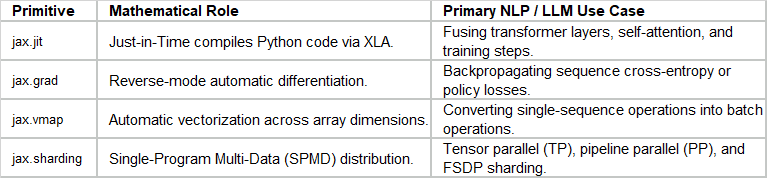

To understand the whole example of this core functionalities, let's have an example like this.

`jax.grad` — Automatic DifferentiationComputes the exact derivative of a function.

$$\text{If } f(x) = x^3 + 2x, \quad \text{then } f'(x) = 3x^2 + 2$$At $x = 3.0$: $f'(3) = 3(3^2) + 2 = 29.0$.

In [19]:
import jax

def f(x):
    return x**3 + 2 * x

df_dx = jax.grad(f)

print(df_dx(3.0))  # Output: 29.0

29.0


`jax.jit` — Just-In-Time CompilationCompiles pure Python/JAX code into fused machine instructions via XLA, skipping Python interpreter overhead.

$$\text{Evaluate } g(x, y) = x \cdot y + x$$

In [23]:
import jax
import jax.numpy as jnp

def g(x, y):
    return x * y + x

fast_g = jax.jit(g)

a = jnp.array([1.0, 2.0, 3.0])
b = jnp.array([4.0, 5.0, 6.0])

print(fast_g(a, b))  # Output: [ 5. 12. 21.]

[ 5. 12. 21.]


In [24]:
import jax
import jax.numpy as jnp

def g(x, y):
    return x * y + x

a = jnp.array([1.0, 2.0, 3.0])
b = jnp.array([4.0, 5.0, 6.0])

print(g(a, b))  # Output: [ 5. 12. 21.]

[ 5. 12. 21.]


`jax.vmap` — Vectorizing Single-Item MathWrite a function for one scalar or 1D vector, and vmap automatically runs it over a batch without manual loops or reshaping.

$$\text{Dot product between two 1D vectors: } \vec{u} \cdot \vec{v} = \sum u_i v_i$$

In [25]:
import jax
import jax.numpy as jnp

def dot_product(u, v):
    return jnp.dot(u, v)

# Vectorize over a batch of 'u' vectors (axis 0), but keep 'v' fixed (None)
batch_dot = jax.vmap(dot_product, in_axes=(0, None))

# A batch of 3 vectors (shape: 3, 2)
U = jnp.array([[1.0, 2.0],
               [3.0, 4.0],
               [5.0, 6.0]])

# A single vector (shape: 2,)
v = jnp.array([10.0, 1.0])

print(batch_dot(U, v))
# Row 0: 1*10 + 2*1 = 12
# Row 1: 3*10 + 4*1 = 34
# Row 2: 5*10 + 6*1 = 56
# Output: [12. 34. 56.]

[12. 34. 56.]


`jax.sharding` — Splitting Arrays Across DevicesDefines which dimensions of an array live on which accelerator (GPU/TPU cores).

$$\text{Split a vector } [1, 2, 3, 4] \text{ across 2 devices} \rightarrow \text{Dev 0}: [1, 2], \quad \text{Dev 1}: [3, 4]$$

In [26]:
import jax
import jax.numpy as jnp
from jax.sharding import Mesh, NamedSharding, PartitionSpec as P

# 1. Create a logical 1D mesh named 'x' across available devices
devices = jax.devices()
mesh = Mesh(devices, axis_names=('x',))

# 2. Define sharding: shard the 0th axis along 'x'
sharding = NamedSharding(mesh, P('x'))

# 3. Place an array onto the devices
arr = jnp.array([10, 20, 30, 40])
sharded_arr = jax.device_put(arr, sharding)

print(sharded_arr.sharding)  # Shows layout across devices

NamedSharding(mesh=Mesh('x': 1, axis_types=(Auto,)), spec=P('x',), memory_kind=device)


In a typical modern neural network training step, all four combine into a single, unified execution pipeline:

1. `vmap` vectors your single-sample model logic across a mini-batch.

2. `grad` wraps the forward loss calculation to compute parameter gradients.

3. `sharding` maps the input batch across data devices and model weights across accelerator cores.

4. `jit` fuses the entire forward pass, backward pass, and parameter update into a single compiled kernel that executes directly on the distributed mesh.



> ## TLDR
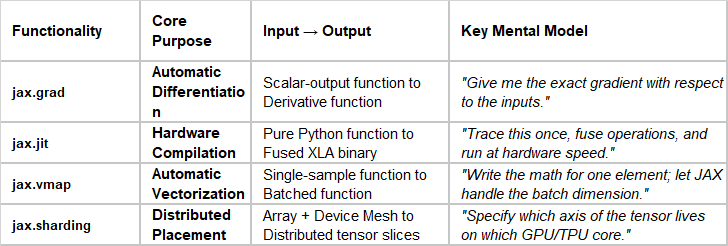



# Functional PRNG (Explicit Randomness)

JAX rejects global random seeds. Every stochastic operation (e.g., dropout, causal mask sampling, token temperature sampling) requires an explicit PRNG key that must be split deterministically.

In [28]:
import jax
import jax.numpy as jnp

# Initialize root PRNG key
rng = jax.random.PRNGKey(69)

# JAX idiom: never reuse the same key twice; always split
rng, dropout_rng, sample_rng = jax.random.split(rng, num=3)

# Dropout mask for embedding layer
dropout_mask = jax.random.bernoulli(dropout_rng, p=0.1, shape=(32, 512, 768))
dropout_mask

Array(shape=(32, 512, 768), dtype=bool)

# PyTrees: Foundation or How State is managed in JAX

In JAX, a PyTree is any nested container structure (lists, tuples, dictionaries, namedtuples, or custom classes) whose terminal leaves are data objects—usually JAX arrays or scalars.

JAX transformations (`jax.jit`, `jax.grad`, `jax.vmap`) natively unpack, transform the leaf arrays, and reconstruct the PyTree while preserving its nested structure.

Unlike PyTorch or TensorFlow, where state is stored internally inside mutable objects (e.g., self.weight inside nn.Module), JAX strictly enforces pure functions without hidden side effects.   

Because in-place mutation is forbidden, state management in JAX is handled explicitly and functionally via PyTrees:   

1. State as Data: Model weights, optimizer states (e.g., Adam momentums), and batch norm statistics are stored as PyTrees.
2. Explicit Passing: You pass the current state PyTree into a function as an argument.
3. Pure Updates: The function computes new arrays and returns a brand-new updated state PyTree using utilities like jax.tree.map.



In [29]:
params = {
    "transformer": {
        "w_q": jnp.ones((768, 768)),
        "w_k": jnp.ones((768, 768))
    }
}

# Scale all weights by a factor of 0.7
scaled_params = jax.tree.map(lambda p: p * 0.7, params)

In JAX, models and optimizers are simply nested data structures (PyTrees) where the actual arrays are the leaves, and the surrounding dictionaries/lists/tuples are the nodes (the treedef).

Here is how to inspect, unpack, and verify a PyTree using `tree_leaves`, `tree_structure`, and `tree_flatten`.

In [30]:
import jax
import jax.numpy as jnp
from jax import tree_util

# Define a nested PyTree of parameters
params = {
    "encoder": {
        "w": jnp.ones((4, 8)),
        "b": jnp.zeros((8,))
    },
    "decoder": {
        "w": jnp.ones((8, 2))
    }
}

# 1. Extract only the array leaves (ignores dict keys and hierarchy)
leaves = tree_util.tree_leaves(params)
print(f"Number of leaf arrays: {len(leaves)}")
print(f"Leaf shapes: {[leaf.shape for leaf in leaves]}")

# 2. Inspect the structure (treedef) without any data
treedef = tree_util.tree_structure(params)
print(f"PyTree structure: {treedef}")

# 3. Flatten into leaves + structure (used internally by jax.jit and jax.grad)
flat_leaves, treedef = tree_util.tree_flatten(params)

# 4. Reconstruct the identical PyTree from flattened leaves
# (e.g., after modifying arrays or passing through an external routine)
doubled_leaves = [x * 2.0 for x in flat_leaves]
reconstructed_params = tree_util.tree_unflatten(treedef, doubled_leaves)

print("Reconstructed decoder weight sum:", jnp.sum(reconstructed_params["decoder"]["w"]))

Number of leaf arrays: 3
Leaf shapes: [(8, 2), (8,), (4, 8)]
PyTree structure: PyTreeDef({'decoder': {'w': *}, 'encoder': {'b': *, 'w': *}})
Reconstructed decoder weight sum: 32.0


# Example of Creating Simple Neural Network from Scratch (2 Layer MLP)

This minimal example trains a 2-layer on synthetic regression data.

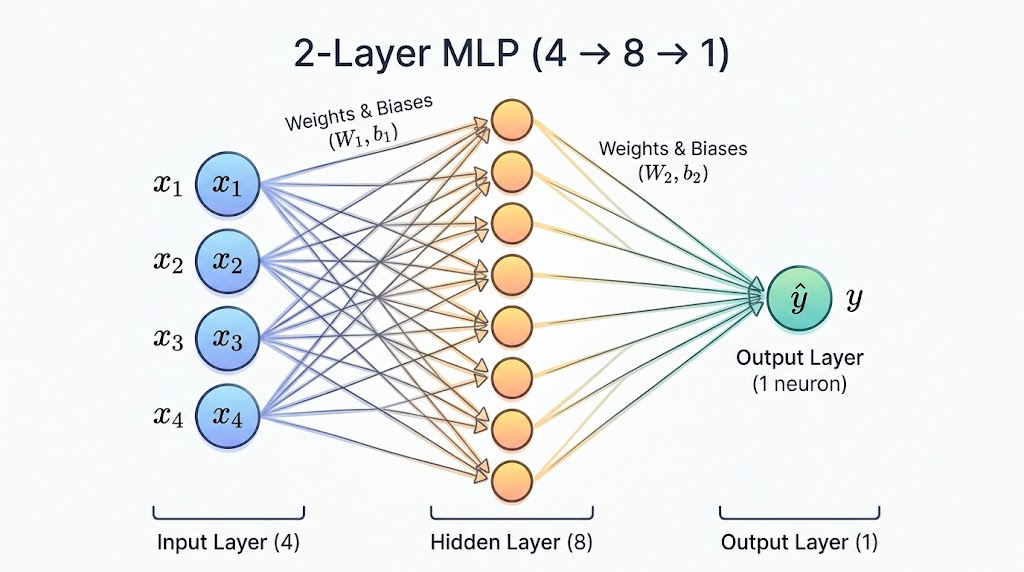

This tutorial discuss several concept from previous using:

* `PyTrees` to hold weights and biases as a plain nested dictionary.

* `jax.grad` (via value_and_grad) to compute derivatives across the parameter tree.

* `jax.jit` to compile the forward pass, backward pass, and parameter update into a single fused step.

In [31]:
import jax
import jax.numpy as jnp

key = jax.random.PRNGKey(69)
k_params1, k_params2, k_data, k_test = jax.random.split(key, 4)

# y = sum(x) + 0.5 * sum(x^2)
def true_target_fn(x):
    return jnp.sum(x, axis=-1, keepdims=True) + 0.5 * jnp.sum(x**2, axis=-1, keepdims=True)

x_train = jax.random.normal(k_data, (64, 4))
y_train = true_target_fn(x_train)

x_test = jax.random.normal(k_test, (16, 4))
y_test = true_target_fn(x_test)
print(x_test[0])
print(y_test[0])



[ 0.40701747 -0.88041985  2.4094386   0.8517877 ]
[6.523693]


In [34]:
params = {
    "layer1": {
        "w": jax.random.normal(k_params1, (4, 16)) * 0.1,
        "b": jnp.zeros((16,))
    },
    "layer2": {
        "w": jax.random.normal(k_params2, (16, 1)) * 0.1,
        "b": jnp.zeros((1,))
    }
}

def forward(params, x):
    h = jnp.dot(x, params["layer1"]["w"]) + params["layer1"]["b"]
    h = jax.nn.relu(h)
    out = jnp.dot(h, params["layer2"]["w"]) + params["layer2"]["b"]
    return out

def mse_loss(params, x, y):
    preds = forward(params, x)
    return jnp.mean((preds - y) ** 2)



In [37]:
@jax.jit
def train_step(params, x, y, lr=0.05):
    loss, grads = jax.value_and_grad(mse_loss)(params, x, y)
    new_params = jax.tree.map(
        lambda p, g: p - lr * g,
        params,
        grads
    )

    return new_params, loss

@jax.jit
def eval_step(params, x, y):
    preds = forward(params, x)
    loss = jnp.mean((preds - y) ** 2)
    return loss, preds

for step in range(1, 200):
    updated_params, loss = train_step(params, x_train, y_train, lr=0.01)
    params = updated_params
    print(f"Step {step} Loss: {loss:.5f}")

Step 1 Loss: 8.44409
Step 2 Loss: 8.22659
Step 3 Loss: 8.01822
Step 4 Loss: 7.81812
Step 5 Loss: 7.62592
Step 6 Loss: 7.44054
Step 7 Loss: 7.26173
Step 8 Loss: 7.08914
Step 9 Loss: 6.92238
Step 10 Loss: 6.76118
Step 11 Loss: 6.60432
Step 12 Loss: 6.45134
Step 13 Loss: 6.30237
Step 14 Loss: 6.15731
Step 15 Loss: 6.01573
Step 16 Loss: 5.87737
Step 17 Loss: 5.74166
Step 18 Loss: 5.60839
Step 19 Loss: 5.47707
Step 20 Loss: 5.34798
Step 21 Loss: 5.22111
Step 22 Loss: 5.09636
Step 23 Loss: 4.97352
Step 24 Loss: 4.85290
Step 25 Loss: 4.73431
Step 26 Loss: 4.61772
Step 27 Loss: 4.50307
Step 28 Loss: 4.39036
Step 29 Loss: 4.27948
Step 30 Loss: 4.17004
Step 31 Loss: 4.06255
Step 32 Loss: 3.95650
Step 33 Loss: 3.85249
Step 34 Loss: 3.75045
Step 35 Loss: 3.65054
Step 36 Loss: 3.55302
Step 37 Loss: 3.45777
Step 38 Loss: 3.36488
Step 39 Loss: 3.27421
Step 40 Loss: 3.18546
Step 41 Loss: 3.09906
Step 42 Loss: 3.01486
Step 43 Loss: 2.93326
Step 44 Loss: 2.85437
Step 45 Loss: 2.77810
Step 46 Loss: 2.704

In [38]:
test_loss, test_preds = eval_step(params, x_test, y_test)
print(f"Final Test MSE Loss: {test_loss:.5f}\n")
print(f"{'Sample #':<10} | {'True Target':<15} | {'Predicted Value':<15} | {'Absolute Error':<15}")
print("-" * 62)

for i in range(0,len(test_preds)):
    target_val = float(y_test[i, 0])
    pred_val = float(test_preds[i, 0])
    err = abs(target_val - pred_val)
    print(f"{i:<10} | {target_val:<15.4f} | {pred_val:<15.4f} | {err:<15.4f}")

Final Test MSE Loss: 0.51764

Sample #   | True Target     | Predicted Value | Absolute Error 
--------------------------------------------------------------
0          | 6.5237          | 5.7389          | 0.7848         
1          | 2.4929          | 2.2287          | 0.2641         
2          | 4.5055          | 4.0642          | 0.4413         
3          | 5.1067          | 4.9190          | 0.1877         
4          | 7.4730          | 7.3684          | 0.1045         
5          | 0.1330          | 0.1629          | 0.0299         
6          | 2.6239          | 3.0861          | 0.4622         
7          | 2.3461          | 2.8128          | 0.4667         
8          | -1.4730         | 0.2310          | 1.7040         
9          | 0.2433          | 0.1734          | 0.0699         
10         | 3.1565          | 4.3574          | 1.2009         
11         | 3.3518          | 3.1696          | 0.1822         
12         | -1.1597         | 0.2577          | 1.4174       

### Summary for Simple NN
Separation of Forward Pass and Updates: forward is pure math and can be used for both training (with `jax.grad`) and inference (without gradient overhead).

`eval_step` with `jax.jit`: Compiles the inference pass to execute efficiently on the test split without allocating buffers for backward passes or parameter updates.

PyTree Immutability: The evaluation function consumes the final params dictionary as a read-only PyTree, producing predictions deterministically.